In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/ConceptualizingConceptDrift')

In [3]:
!pip install xplique wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 39.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

import torch
import numpy as np
import random
import string
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
from IPython.core.display import display, HTML
from sklearn.model_selection import train_test_split

from experiment_helpers.helper_function import *
from experiment_helpers.driftLocalizer import Localizer
from text_helpers.CraftText import (
    CraftText, CraftTextCombined, full_text_activations,
    top_sentences, occlusion_concepts_text, occlusion_global_keywords
)
from text_helpers.CustomBertModel import CustomBertForSequenceClassification

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords

np.random.seed(42)
random.seed(42)

device = 'cuda'
patch_mode = "window"

ignore_list = stopwords.words('english') + list(string.punctuation) + ["'s", "n't", "'re", "'ve", "'ll", "'d", "'m"]

checkpoint_name = "fabriceyhc/bert-base-uncased-dbpedia_14"
model = CustomBertForSequenceClassification.from_pretrained(checkpoint_name, num_labels=14)
model = model.eval().to(device)
tokenizer = AutoTokenizer.from_pretrained(checkpoint_name)

dbpedia = load_dataset("fancyzhx/dbpedia_14")

all_texts = list(dbpedia["train"]["content"])
all_labels = np.array(dbpedia["train"]["label"])

idd_class_ids = [2, 3, 4, 11, 12, 13]

subset_mask = np.isin(all_labels, idd_class_ids)
texts = [t for t, m in zip(all_texts, subset_mask) if m]
labels = all_labels[subset_mask]

sample_ids = np.random.choice(len(texts), 500, False)
sample_texts = [texts[i] for i in sample_ids]

label_map = {
    2:  0,   # Artist -> BD
    3:  1,   # Athlete -> AD
    4:  2,   # OfficeHolder -> Both
    11: 0,   # Album -> BD
    12: 1,   # Film -> AD
    13: 2,   # WrittenWork -> Both
}

labels_mapped = np.array([label_map[class_id] for class_id in labels])
drift_labels = labels_mapped[sample_ids]

label_2_idx = np.where(drift_labels == 2)[0]
y_mixed = drift_labels.copy()
y_mixed[label_2_idx] = np.random.choice([0, 1], size=len(label_2_idx))

sample_labels = y_mixed

patch_act = full_text_activations(sample_texts, model, tokenizer, device=device)
train_labels = sample_labels

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


config.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

...

dbpedia_14/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

dbpedia_14/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 13.3MB            

dbpedia_14/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70000 [00:00<?, ? examples/s]

In [5]:
bd_indices = np.where(sample_labels != 1)[0]
ad_indices = np.where(sample_labels != 0)[0]

In [6]:
bd_texts = [sample_texts[i] for i in bd_indices]
bd_labels = [sample_labels[i] for i in bd_indices]
ad_texts = [sample_texts[i] for i in ad_indices]
ad_labels = [sample_labels[i] for i in ad_indices]

bd_fit = CraftText(model_wrapper=model, tokenizer=tokenizer, num_concepts=10,
                    patch_mode=patch_mode, win_size=15, stride=10, device=device)
print("Fitting Unsupervised Craft....")
bd_crops, bd_crops_u, bd_w = bd_fit.fit(bd_texts, bd_labels)

ad_fit = CraftText(model_wrapper=model, tokenizer=tokenizer, num_concepts=10,
                    patch_mode=patch_mode, win_size=15, stride=10, device=device)
print("Fitting Unsupervised Craft....")
ad_crops, ad_crops_u, ad_w = ad_fit.fit(ad_texts, ad_labels)

drift_basis = np.vstack([bd_w, ad_w])

drift_craft = CraftTextCombined(model_wrapper=model, tokenizer=tokenizer, basis=drift_basis,
                                 patch_mode=patch_mode, win_size=15, stride=10, device=device)
print("Fitting Craft....")
drift_craft.transform_all(sample_texts, sample_labels)

Fitting Unsupervised Craft....
Fitting Unsupervised Craft....
Fitting Craft....


array([[3.9537015e-05, 4.2136588e-09, 1.1777237e-07, ..., 8.7523216e-04,
        5.6891190e-07, 3.2623299e-13],
       [3.1792521e-03, 2.1685983e-06, 1.4548377e-07, ..., 8.1895626e-01,
        1.1631176e-05, 2.6550651e-01],
       [7.0337165e-07, 1.1826828e+00, 7.0604598e-05, ..., 1.6091808e-03,
        3.3098449e-06, 1.2620050e-01],
       ...,
       [1.6757863e-06, 1.1893106e-19, 2.5125222e-02, ..., 2.1997639e-06,
        1.0078824e-02, 4.9597383e-15],
       [1.3532171e-19, 1.1929149e-12, 1.0714432e-01, ..., 4.4896577e-19,
        3.6985190e-03, 2.0085574e-12],
       [6.8262182e-08, 1.1891240e+00, 4.6734693e-03, ..., 2.7919125e-06,
        5.5239780e-05, 8.3157187e-03]], dtype=float32)

In [7]:
X_clean = patch_act
y_clean = sample_labels

X_train_clean, X_test_clean, y_train, y_test, idx_train, idx_test = \
    train_test_split(X_clean, y_clean, np.arange(len(X_clean)), train_size=0.7, random_state=42)
test_texts = [sample_texts[i] for i in idx_test]

localizer = Localizer(min_samples_leaf=20)
localizer.fit(X_train_clean, y_train)


low threshold: 0.35 Mean:0.5114285714285715 High threshold:0.7, No. Leaves:20


Localizer(min_samples_leaf=20)

In [8]:
drift_imp = np.round(estimate_importance_l(localizer, drift_craft, drift_basis, X_train_clean), 3)

y_preds, _ = l_compute_predictions(localizer, X_test_clean)

image_drift_imp = [
    estimate_importance_helper_l(drift_craft, localizer, drift_basis, text_vec, class_of_interest=y_preds[i])
    for i, text_vec in enumerate(X_test_clean)
]

y_train_preds, _ = l_compute_predictions(localizer, X_train_clean)

image_drift_imp_train = [
    estimate_importance_helper_l(drift_craft, localizer, drift_basis, text_vec, class_of_interest=y_train_preds[i])
    for i, text_vec in enumerate(X_train_clean)
]


/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

In [9]:
print(image_drift_imp[0])
print(accuracy_score(y_preds, y_test))

[0.0000000e+00 0.0000000e+00 8.7447542e-01 4.7181284e-06 0.0000000e+00
 0.0000000e+00 2.2122844e-03 4.7181284e-06 1.0467307e-02 7.5459160e-05
 0.0000000e+00 0.0000000e+00 7.5459160e-05 7.0741036e-05 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 5.8228686e-04 0.0000000e+00]
0.84


In [10]:
dist_dict = concept_counter(image_drift_imp_train, y_train_preds)
bd_dist = dist_dict[0]
ad_dist = dist_dict[1]
print(dist_dict)

{0: {np.int64(4): 0.2857142857142857, np.int64(2): 0.291005291005291, np.int64(1): 0.2962962962962963, np.int64(12): 0.005291005291005291, np.int64(13): 0.0582010582010582, np.int64(9): 0.0582010582010582, np.int64(8): 0.005291005291005291}, 1: {np.int64(16): 0.36645962732919257, np.int64(15): 0.4161490683229814, np.int64(11): 0.037267080745341616, np.int64(13): 0.12422360248447205, np.int64(9): 0.031055900621118012, np.int64(4): 0.018633540372670808, np.int64(7): 0.006211180124223602}}


In [11]:
print(local_imp_concepts_probability(dist_dict, image_drift_imp, 1, y_test))
print(local_one_imp_concept_globally_l(drift_craft, image_drift_imp, y_test))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 1, y_test))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 2, y_test))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 3, y_test))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 1, y_test))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 2, y_test))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 3, y_test))

0.7866666666666666
0.8
0.8
0.8
0.7933333333333333
0.6666666666666666
0.7733333333333333
0.8


In [12]:
print(local_imp_concepts_probability(dist_dict, image_drift_imp, 1, y_preds))
print(local_one_imp_concept_globally_l(drift_craft, image_drift_imp, y_preds))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 1, y_preds))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 2, y_preds))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 3, y_preds))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 1, y_preds))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 2, y_preds))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 3, y_preds))

0.92
0.9333333333333333
0.9333333333333333
0.9333333333333333
0.94
0.7733333333333333
0.8666666666666667
0.9333333333333333


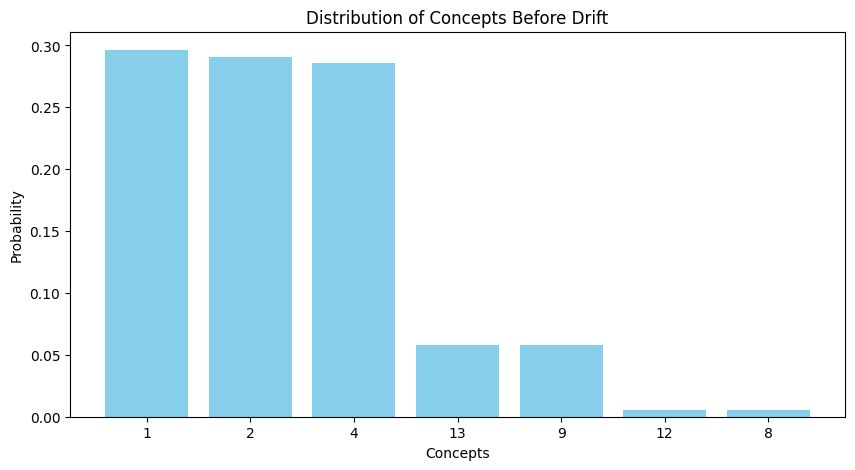

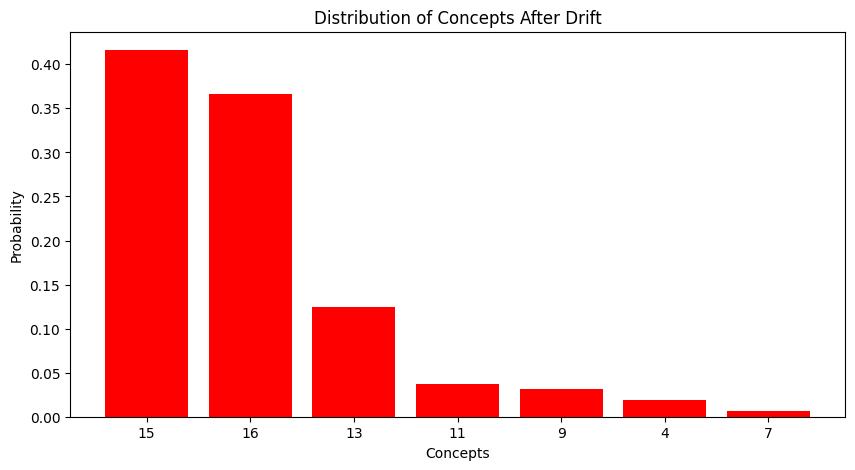

In [13]:
from collections import Counter
import matplotlib.pyplot as plt

sample_local_imp = np.array(image_drift_imp_train)
before_drift_counter = Counter()
after_drift_counter = Counter()

for drift_label in np.unique(y_train):
    drift_fil = y_train_preds == drift_label
    for imp in sample_local_imp[drift_fil]:
        local_imp_sort = np.argsort(imp)[::-1][0]
        if drift_label == 0:
            before_drift_counter[local_imp_sort] += 1
        elif drift_label == 1:
            after_drift_counter[local_imp_sort] += 1

total_before = sum(before_drift_counter.values())
total_after = sum(after_drift_counter.values())

before_drift_dist = {c: n / total_before for c, n in before_drift_counter.items()}
after_drift_dist = {c: n / total_after for c, n in after_drift_counter.items()}

sorted_before = sorted(before_drift_dist.items(), key=lambda x: x[1], reverse=True)
sorted_after = sorted(after_drift_dist.items(), key=lambda x: x[1], reverse=True)

def plot_distribution(dist, title, color):
    concepts, probs = zip(*dist)
    plt.figure(figsize=(10, 5))
    plt.bar([str(c) for c in concepts], probs, color=color)
    plt.xlabel('Concepts')
    plt.ylabel('Probability')
    plt.title(title)
    plt.show()

plot_distribution(sorted_before, "Distribution of Concepts Before Drift", "skyblue")
plot_distribution(sorted_after, "Distribution of Concepts After Drift", "red")

In [14]:
idx = 1

top5_concepts = list(set([c for c, _ in sorted_before[:5]] + [c for c, _ in sorted_after[:5]]))
local_top5 = list(np.argsort(image_drift_imp[idx])[::-1][:5])

In [15]:
all_relevant_concepts = sorted(set(top5_concepts) | set(local_top5))
color_map = cm.get_cmap('tab20')
colors_rgba = {c: f"rgba({int(color_map(i)[0]*255)},{int(color_map(i)[1]*255)},{int(color_map(i)[2]*255)}," for i, c in enumerate(all_relevant_concepts)}
colors_hex = {c: color_map(i) for i, c in enumerate(all_relevant_concepts)}

/tmp/ipykernel_1542/972296876.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab20')


/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

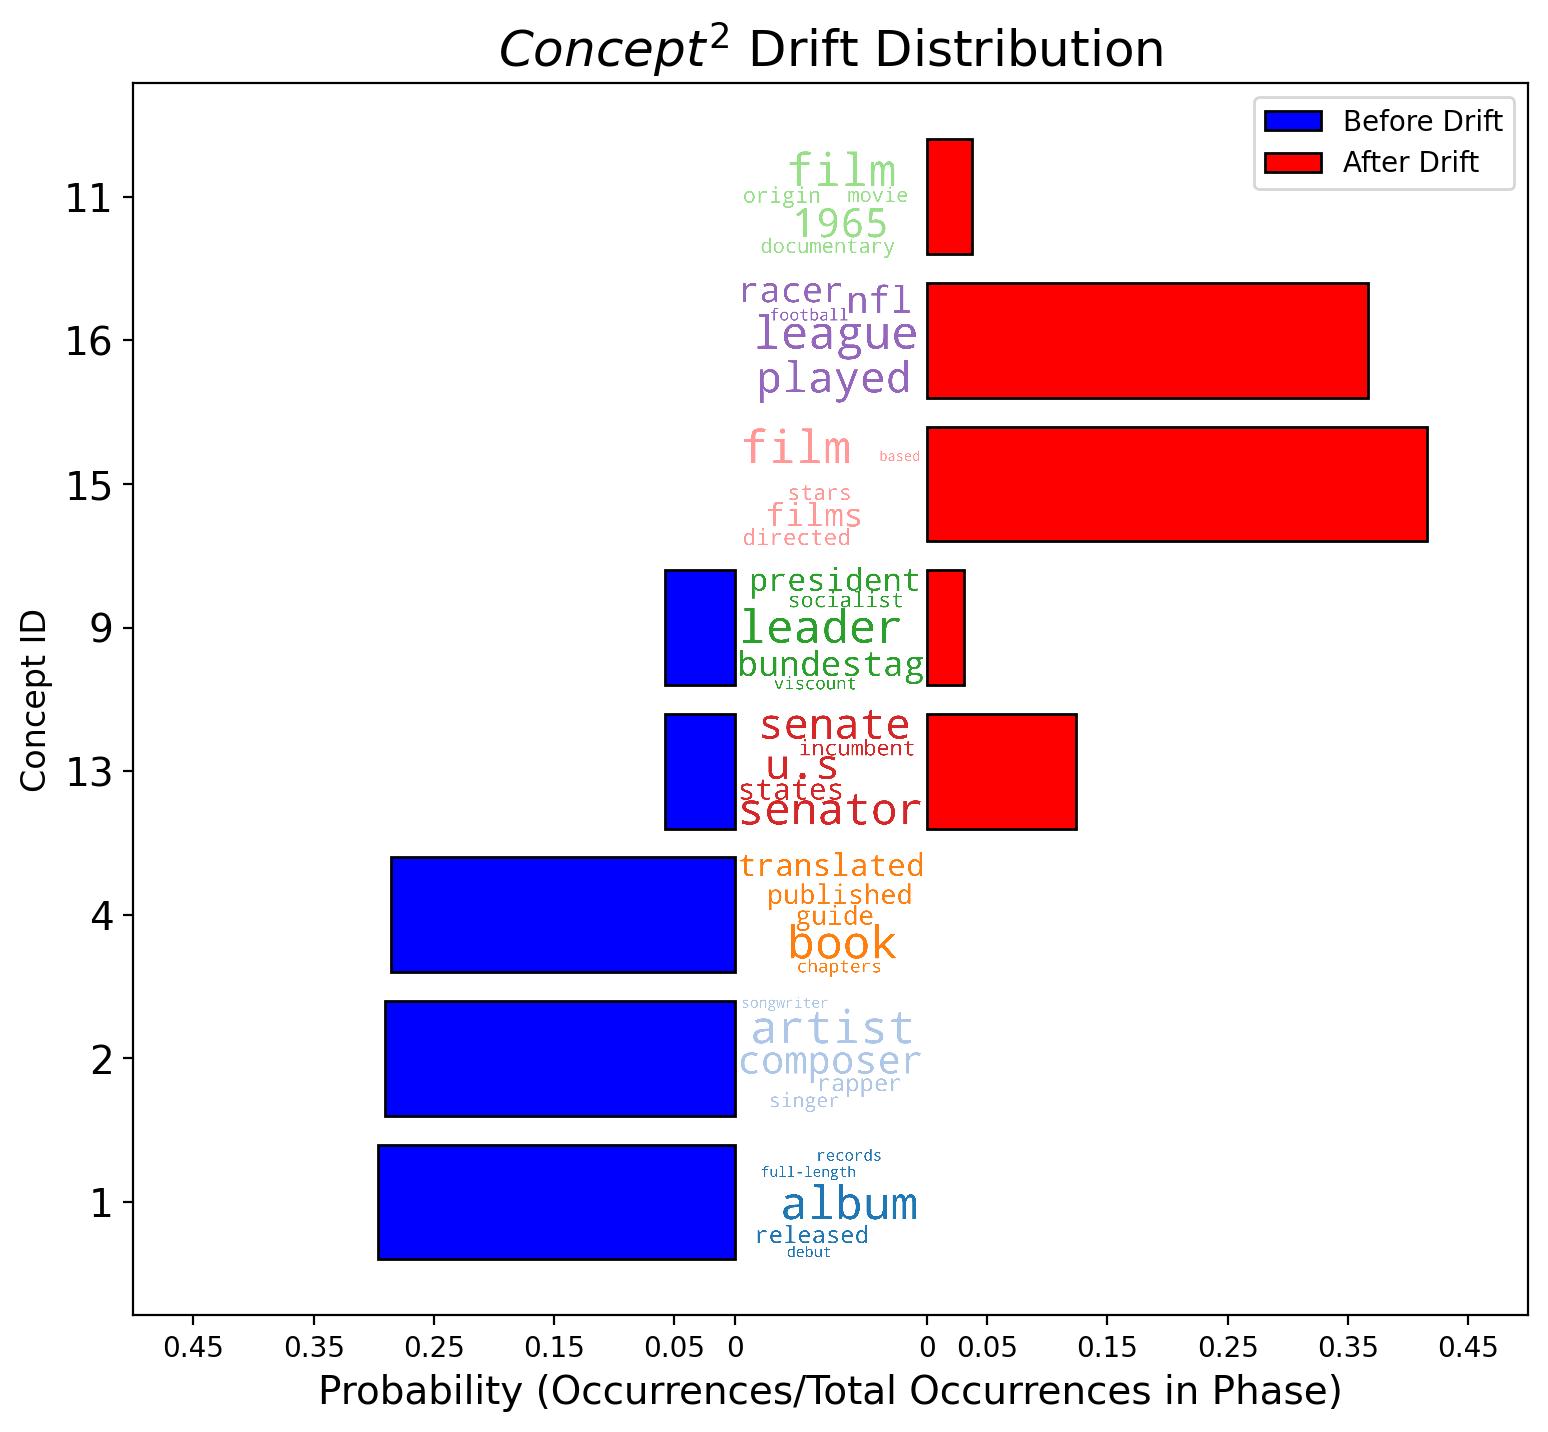

In [ ]:
from wordcloud import WordCloud
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


def concept_wordcloud(concept, color):
    keyword_freqs = occlusion_global_keywords(
        concept, drift_craft.embedding, drift_craft.crops, drift_basis,
        model, tokenizer, ignore_list, top_n_patches=20, top_n_words=5, device=device
    )
    if len(keyword_freqs) == 0:
        keyword_freqs = {"n/a": 1}
    hex_color = f"#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}"
    return WordCloud(width=900, height=600, background_color="white",
                     min_font_size=28, max_font_size=220, prefer_horizontal=1.0,
                     color_func=lambda *args, **kwargs: hex_color).generate_from_frequencies(keyword_freqs)


def get_colored_wordcloud_image(concept, color):
    return OffsetImage(np.array(concept_wordcloud(concept, color)), zoom=0.075)


def plot_distribution_with_wordclouds(bd_dist, ad_dist):
    bd_concepts, bd_probs = zip(*bd_dist[:5])
    ad_concepts, ad_probs = zip(*ad_dist[:5])

    ad_probs = np.array(ad_probs)
    bd_probs = np.array(bd_probs)
    ad_concepts_str = np.array(ad_concepts).astype(str)
    bd_concepts_str = np.array(bd_concepts).astype(str)

    all_concepts_raw = list(bd_concepts) + list(ad_concepts)
    all_concepts_str = np.append(bd_concepts_str, ad_concepts_str)

    fig, ax = plt.subplots(figsize=(9, 8), dpi=200)
    bar_offset = 0.08  

    ax.barh(bd_concepts_str, -bd_probs, color='blue', edgecolor="black", label='Before Drift', left=-bar_offset)
    ax.barh(ad_concepts_str, ad_probs, color='red', edgecolor="black", label='After Drift', left=bar_offset)

    for concept_raw, concept_str in zip(all_concepts_raw, all_concepts_str):
        image = get_colored_wordcloud_image(int(concept_raw), colors_hex[concept_raw])
        ab = AnnotationBbox(image, (0, concept_str), frameon=False)
        ax.add_artist(ab)

    ax.set_yticks(np.unique(all_concepts_str))
    ax.set_yticklabels([f"{c}" for c in np.unique(all_concepts_str)], fontsize=14)

    tick_values = [0.45, 0.35, 0.25, 0.15, 0.05]
    tick_positions = [-(v + bar_offset) for v in tick_values] + [-bar_offset, bar_offset] + [v + bar_offset for v in tick_values[::-1]]
    tick_labels = ["0.45", "0.35", "0.25", "0.15", "0.05", "0", "0", "0.05", "0.15", "0.25", "0.35", "0.45"]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(-(0.5 + bar_offset), 0.5 + bar_offset)

    ax.set_xlabel("Probability (Occurrences/Total Occurrences in Phase)", fontsize=14)
    ax.set_ylabel("Concept ID", fontsize=12)
    ax.set_title("$Concept^2$ Drift Distribution", fontsize=18)
    ax.legend()
    plt.show()


plot_distribution_with_wordclouds(sorted_before, sorted_after)


In [17]:
print(f"text: {test_texts[idx]}")
print(f"label: {y_test[idx]}  pred: {y_preds[idx]}")

local_imp = image_drift_imp[idx]
top_concept = np.argsort(local_imp)[::-1][0]
print(f"top concept: {top_concept}")

text:  A Quiet week in the House (Czech: Tichý týden v dome) is a 1969 Czechoslovak live-action/animated short film by Jan Švankmajer.
label: 1  pred: 1
top concept: 15


In [18]:
words, importances = occlusion_concepts_text(
    test_texts[idx].lower(), model, tokenizer, drift_basis,
    concept_ids=local_top5, ignore_words=ignore_list, device=device
)

phi_all = np.array(importances)
global_max = np.max(np.abs(phi_all)) + 1e-5
phi_all_norm = phi_all / global_max
phi_display = np.sign(phi_all_norm) * np.sqrt(np.clip(np.abs(phi_all_norm), 0, 1))

phi_html = []
for i in range(len(words)):
    k = np.argmax(phi_display[:, i])
    val = phi_display[k, i]
    if val > 0.25:
        phi_html.append(f'<span style="background-color: {colors_rgba[local_top5[k]]}{val:.2f}); padding: 1px 5px;">{words[i]}</span>')
    else:
        phi_html.append(f'<span style="padding: 1px 5px;">{words[i]}</span>')
display(HTML("<div style='display: flex; width: 500px; flex-wrap: wrap'>" + " ".join(phi_html) + "</div>"))

In [19]:
words_global, importances_global = occlusion_concepts_text(
    test_texts[idx].lower(), model, tokenizer, drift_basis,
    concept_ids=top5_concepts, ignore_words=ignore_list, device=device
)
phi_global = np.array(importances_global)
phi_global_norm = phi_global / (np.max(np.abs(phi_global)) + 1e-5)
phi_global_display = np.sign(phi_global_norm) * np.sqrt(np.clip(np.abs(phi_global_norm), 0, 1))

phi_html_global = []
for i in range(len(words_global)):
    k = np.argmax(phi_global_display[:, i])
    val = phi_global_display[k, i]
    if val > 0.25:
        phi_html_global.append(f'<span style="background-color: {colors_rgba[top5_concepts[k]]}{val:.2f}); padding: 1px 5px;">{words_global[i]}</span>')
    else:
        phi_html_global.append(f'<span style="padding: 1px 5px;">{words_global[i]}</span>')
display(HTML("<div style='display: flex; width: 500px; flex-wrap: wrap'>" + " ".join(phi_html_global) + "</div>"))

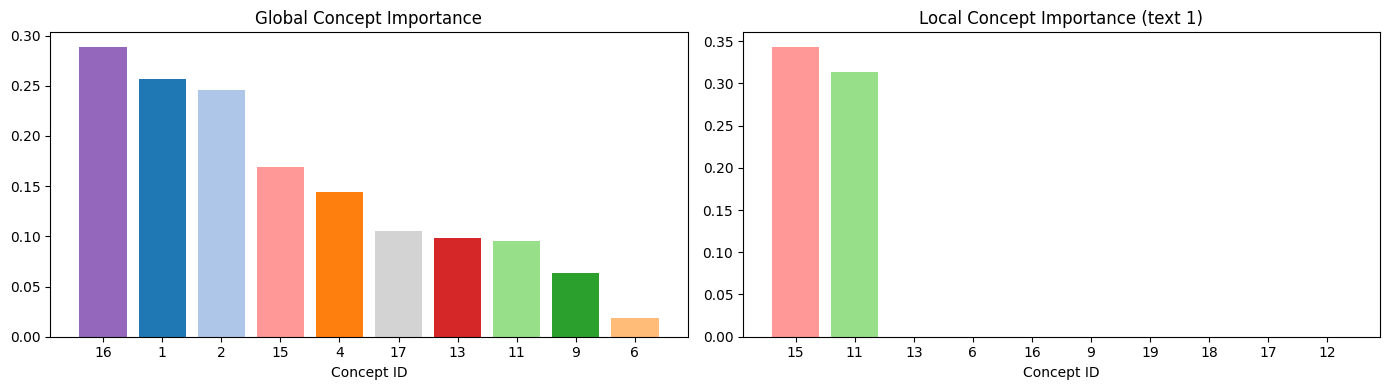

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

global_importance = np.maximum(drift_craft.sensitivities[0].importances, drift_craft.sensitivities[1].importances)
top_idx_g = np.argsort(global_importance)[::-1][:10]
bar_colors_g = [colors_hex[c] if c in colors_hex else "lightgray" for c in top_idx_g]
axes[0].bar([str(i) for i in top_idx_g], global_importance[top_idx_g], color=bar_colors_g)
axes[0].set_title("Global Concept Importance")
axes[0].set_xlabel("Concept ID")

local_importance = image_drift_imp[idx]
top_idx_l = np.argsort(local_importance)[::-1][:10]
bar_colors_l = [colors_hex[c] if c in colors_hex else "lightgray" for c in top_idx_l]
axes[1].bar([str(i) for i in top_idx_l], local_importance[top_idx_l], color=bar_colors_l)
axes[1].set_title(f"Local Concept Importance (text {idx})")
axes[1].set_xlabel("Concept ID")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

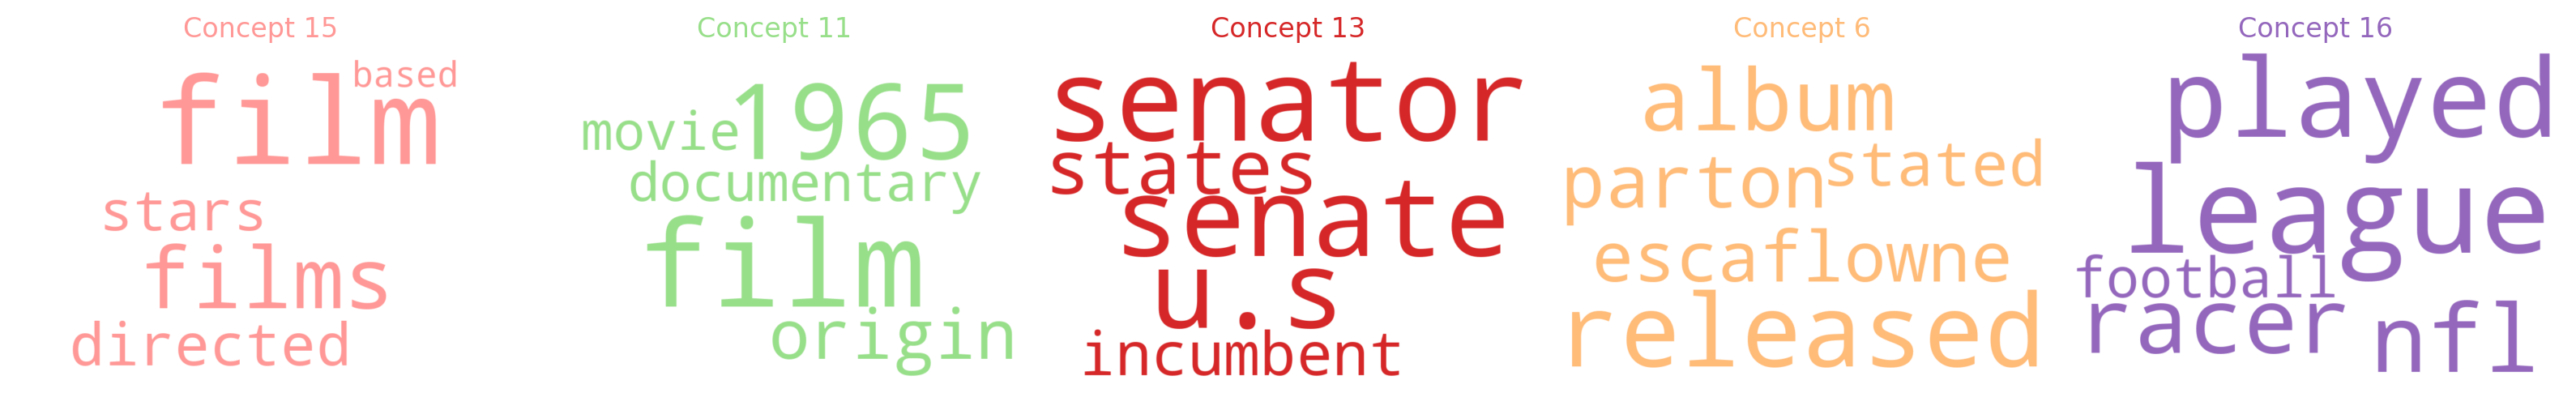

/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

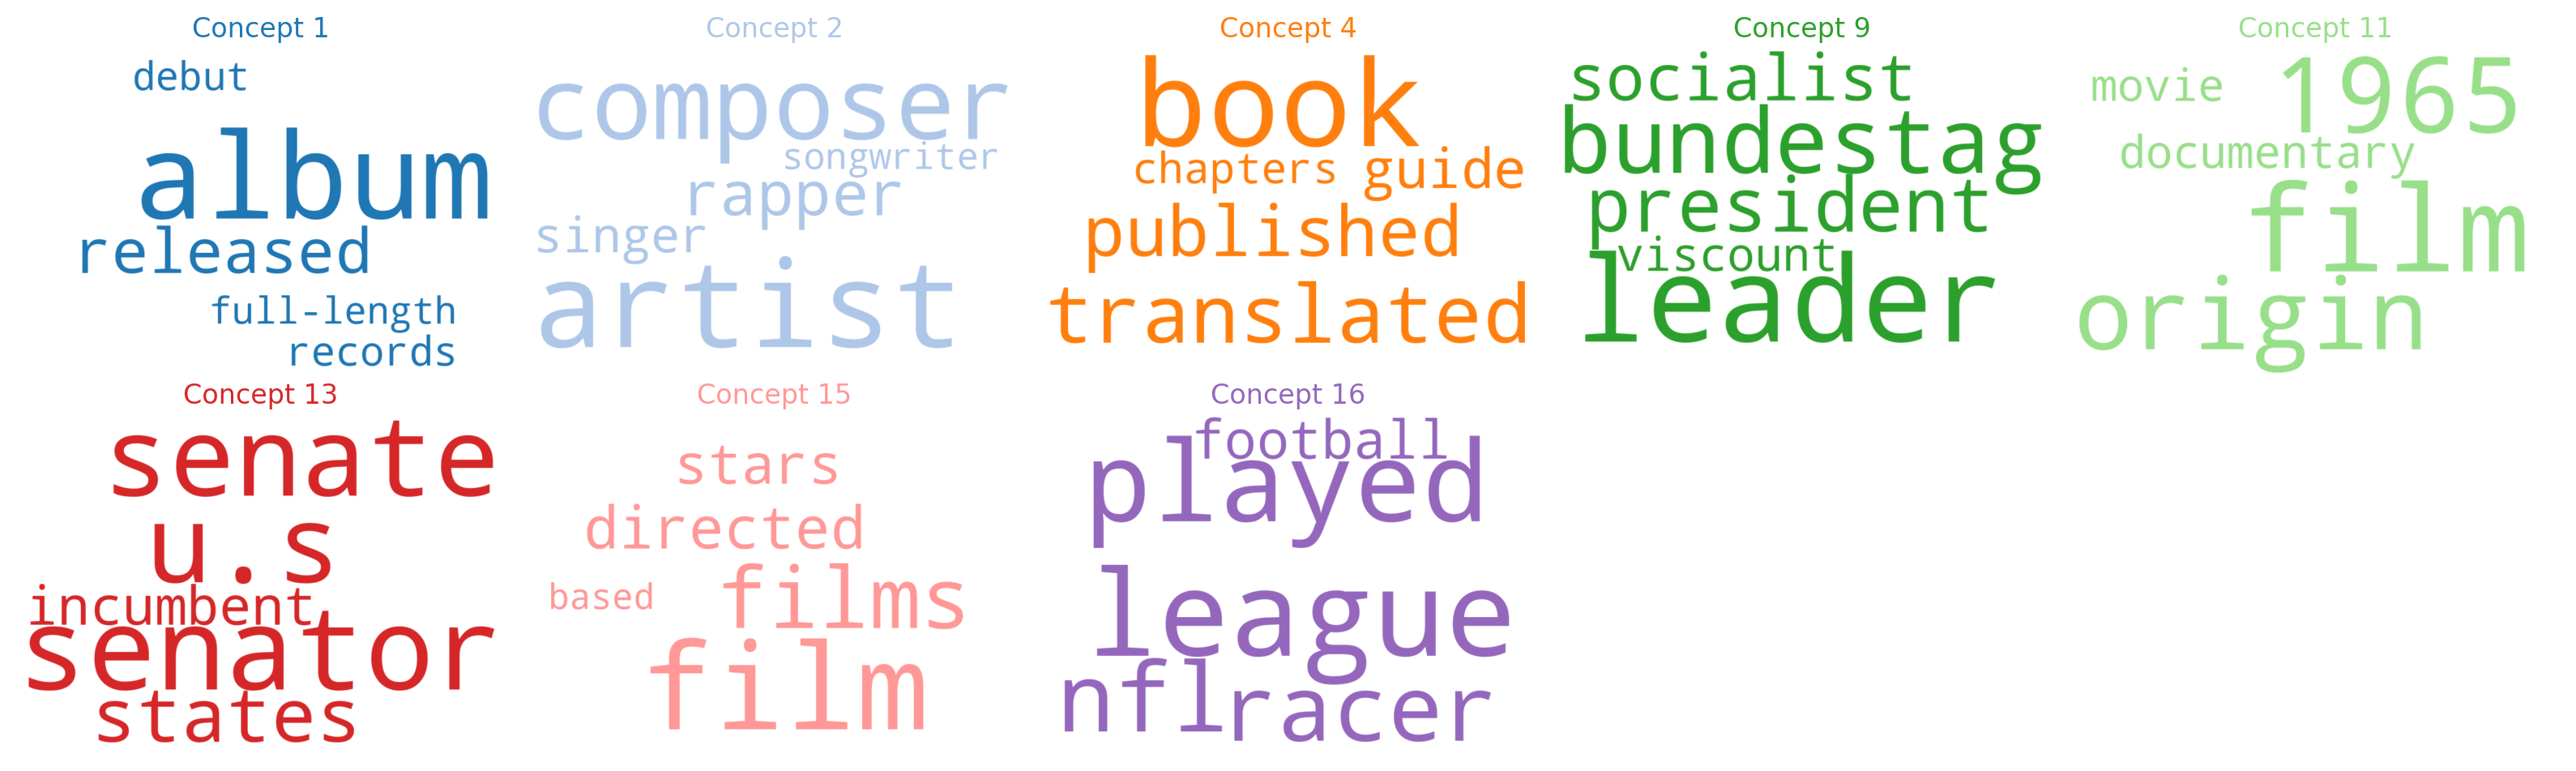

In [ ]:
def plot_concept_wordclouds(concept_ids, per_row=5):
    n = len(concept_ids)
    rows = int(np.ceil(n / per_row))
    fig, axes = plt.subplots(rows, per_row, figsize=(3.2 * per_row, 2.4 * rows), dpi=200)
    axes = np.array(axes).reshape(-1)
    for ax, concept in zip(axes, concept_ids):
        ax.imshow(np.array(concept_wordcloud(int(concept), colors_hex[concept])), interpolation="bilinear")
        ax.set_title(f"Concept {concept}", fontsize=12, color=colors_hex[concept])
        ax.axis("off")
    for ax in axes[len(concept_ids):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_concept_wordclouds(local_top5)
plot_concept_wordclouds(top5_concepts)
